# 01 — Trends & Visuals

Этот ноутбук показывает “витринные” визуализации трендов:
- heatmap Topics×Time (share и z-score)
- trending now по Δshare
- сравнение нескольких тем на одном графике

Данные берутся из `artifacts/ui/*`.

In [1]:
# imports + load

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

UI_DIR = Path("..") / "artifacts" / "ui"
assert UI_DIR.exists(), f"UI bundle not found: {UI_DIR.resolve()}"

topics = pd.read_parquet(UI_DIR / "topics.parquet")
topics_info = pd.read_parquet(UI_DIR / "topics_info.parquet")
trends = pd.read_parquet(UI_DIR / "trends.parquet")

topics["created_at"] = pd.to_datetime(topics["created_at"], utc=True, errors="coerce")
trends["time_bin"] = pd.to_datetime(trends["time_bin"], utc=True, errors="coerce")

topics["topic_id"] = pd.to_numeric(topics["topic_id"], errors="coerce").fillna(-1).astype(int)
topics["topic_prob"] = pd.to_numeric(topics["topic_prob"], errors="coerce")

if "Topic" in topics_info.columns and "topic_id" not in topics_info.columns:
    topics_info = topics_info.rename(columns={"Topic": "topic_id"})
topics_info["topic_id"] = pd.to_numeric(topics_info["topic_id"], errors="coerce").fillna(-1).astype(int)
if "keywords" not in topics_info.columns:
    topics_info["keywords"] = topics_info.get("Representation", "")

for c in ["share", "growth", "n_posts", "avg_prob"]:
    if c in trends.columns:
        trends[c] = pd.to_numeric(trends[c], errors="coerce")

print("topics:", topics.shape)
print("topics_info:", topics_info.shape)
print("trends:", trends.shape)

topics: (723039, 6)
topics_info: (100, 8)
trends: (34222, 7)


In [2]:
# choose period preset

# Choose a showcase period (adjust freely)
start = pd.Timestamp("2018-01-01", tz="UTC")
end = pd.Timestamp("2020-12-31", tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

tr = trends[(trends["time_bin"] >= start) & (trends["time_bin"] <= end)].copy()
print("period:", start.date(), "..", end.date(), "| rows:", len(tr))
assert len(tr) > 0, "Empty period slice. Pick another range."

period: 2018-01-01 .. 2020-12-31 | rows: 2469


In [3]:
# build heatmap matrix: share

topic_total = tr.groupby("topic_id")["share"].sum().sort_values(ascending=False)
topic_ids = [int(t) for t in topic_total.index.tolist() if int(t) != -1][:60]

mat = tr[tr["topic_id"].isin(topic_ids)].pivot_table(
    index="topic_id", columns="time_bin", values="share", aggfunc="mean"
).fillna(0.0)

mat.shape

(60, 38)

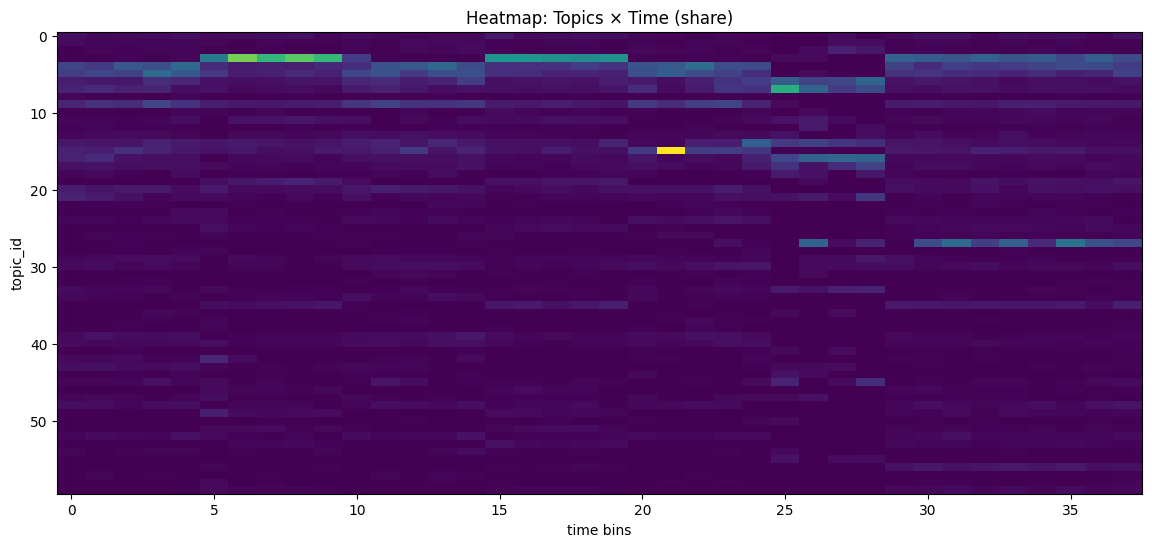

In [8]:
# heatmap plot: share

plt.figure(figsize=(14, 6))
plt.imshow(mat.values, aspect="auto")
plt.title("Heatmap: Topics × Time (share)")
plt.xlabel("time bins")
plt.ylabel("topic_id")
plt.show()

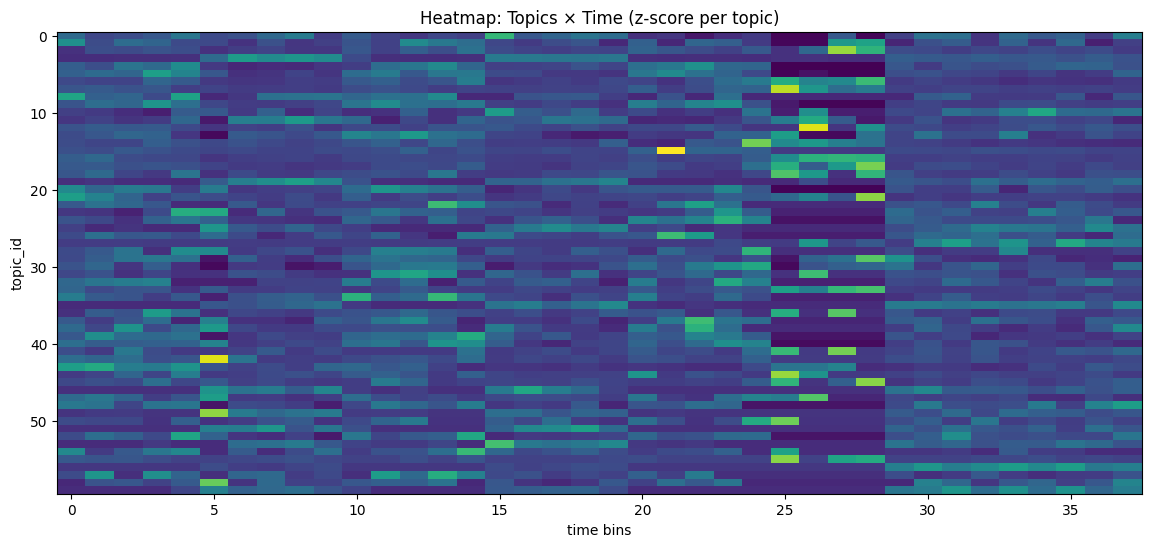

In [9]:
# heatmap plot: z-score per topic

mu = mat.mean(axis=1)
sigma = mat.std(axis=1).replace(0, np.nan)
zmat = (mat.sub(mu, axis=0)).div(sigma, axis=0).fillna(0.0)

plt.figure(figsize=(14, 6))
plt.imshow(zmat.values, aspect="auto")
plt.title("Heatmap: Topics × Time (z-score per topic)")
plt.xlabel("time bins")
plt.ylabel("topic_id")
plt.show()

In [6]:
# trending now: Δshare

sub = tr[tr["topic_id"].isin(topic_ids)].sort_values(["topic_id", "time_bin"])

first = sub.groupby("topic_id", as_index=False).first()[["topic_id", "share"]].rename(columns={"share": "share_first"})
last = sub.groupby("topic_id", as_index=False).last()[["topic_id", "share", "n_posts", "avg_prob", "growth"]].rename(
    columns={"share": "share_last", "n_posts": "n_last"}
)

rank = first.merge(last, on="topic_id", how="inner")
rank["delta_share"] = rank["share_last"] - rank["share_first"]

rank = rank.merge(topics_info[["topic_id", "keywords"]], on="topic_id", how="left")
rank = rank.sort_values("delta_share", ascending=False)

rank.head(15)

,topic_id,share_first,share_last,n_last,avg_prob,growth,delta_share,keywords
3,3,0.002333,0.063794,114,0.684322,-0.469767,0.061461,"[trip, travel, we, to, in, days, day, stay, an..."
27,34,0.001732,0.059877,107,0.467990,-0.392045,0.058145,"[shirt, vintage, shoes, retro, fashion, indepe..."
19,21,0.000866,0.014550,26,0.656143,-0.037037,0.013684,"[india, tour, packages, nepal, delhi, kerala, ..."
35,47,0.009836,0.023503,42,0.807835,0.750000,0.013667,"[flight, airlines, flights, tickets, booking, ..."
56,92,0.003279,0.012871,23,0.969926,-0.206897,0.009592,"[covid, canada, removed, visa, travel, 19, pan..."
48,69,0.010390,0.015109,27,0.611428,-0.100000,0.004720,"[python, django, programming, learn, deleted, ..."
59,97,0.001684,0.006156,11,0.931496,0.000000,0.004472,"[passport, passports, us, expired, entry, rene..."
25,32,0.001732,0.006156,11,0.813676,-0.500000,0.004424,"[map, art, photos, lake, history, maps, museum..."
45,64,0.003463,0.007834,14,0.230353,0.000000,0.004371,"[drone, drones, helicopter, dji, quadcopter, m..."
52,78,0.004329,0.008394,15,0.767798,0.500000,0.004065,"[github, git, repositories, version, repos, co..."


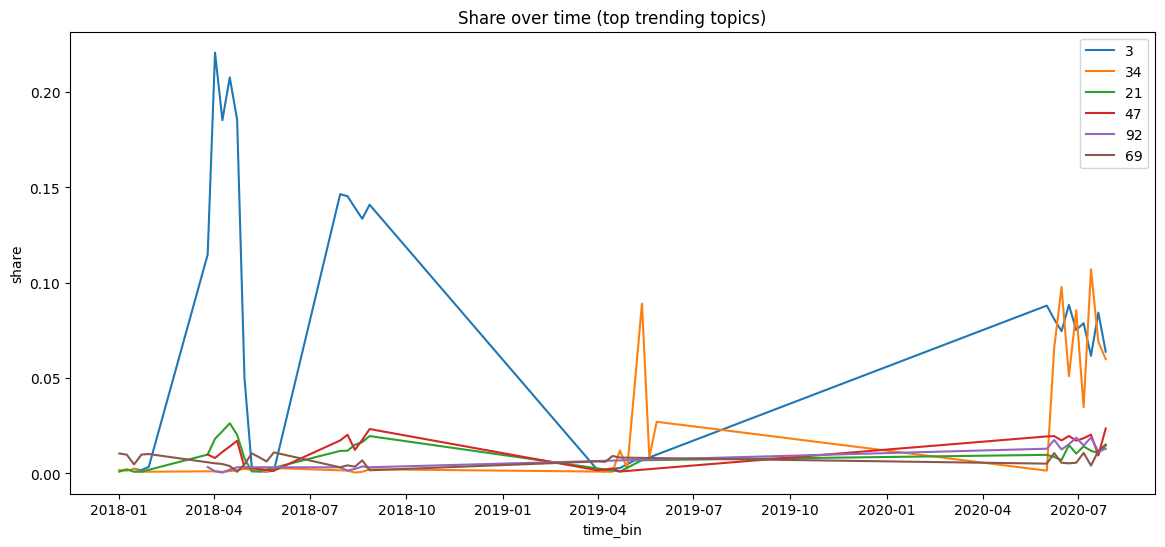

In [10]:
# multi-topic compare lines

top_compare = rank.head(6)["topic_id"].astype(int).tolist()
sub2 = tr[tr["topic_id"].isin(top_compare)].copy().sort_values("time_bin")

plt.figure(figsize=(14, 6))
for tid in top_compare:
    s = sub2[sub2["topic_id"] == tid].sort_values("time_bin")
    plt.plot(s["time_bin"], s["share"], label=str(tid))

plt.title("Share over time (top trending topics)")
plt.xlabel("time_bin")
plt.ylabel("share")
plt.legend()
plt.show()

## Conclusions — Trends & Dynamics

**Temporal structure**
- Анализ недельных бинов показывает, что темы ведут себя **неравномерно во времени**:
  - часть тем демонстрирует долгосрочный устойчивый интерес,
  - часть — резкие краткосрочные всплески,
  - часть — затухающую динамику.

Это подтверждает, что агрегация по времени является критически важной частью анализа социальных потоков.

**Heatmap (absolute share)**
- Heatmap по абсолютной доле (`share`) хорошо выявляет:
  - “фоновые” крупные темы,
  - периоды их усиления и ослабления.
- Однако для небольших, но быстро растущих тем абсолютная доля часто остаётся визуально незаметной.

**Heatmap (z-score per topic)**
- Z-score нормализация по каждой теме резко улучшает обнаружение:
  - локальных всплесков интереса,
  - аномальных периодов,
  - синхронных изменений между разными темами.
- Такой режим особенно полезен для **exploratory trend analysis**, когда важны относительные изменения, а не абсолютные масштабы.

**Trending now (Δshare ranking)**
- Ранжирование по `Δshare` (разница долей между началом и концом периода):
  - устойчиво выделяет темы с реальным ростом,
  - менее чувствительно к шуму, чем относительный `growth`,
  - лучше отражает “что стало важнее”, а не просто “что маленькое выросло в 2 раза”.

**Multi-topic comparison**
- Совместные line-графики нескольких тем показывают:
  - асинхронность трендов,
  - возможные конкурентные отношения между темами,
  - различие между краткосрочными всплесками и долгими трендами.
- Такой вид сравнения удобен для гипотез о смене интересов аудитории.

**Overall assessment**
- Комбинация:
  - absolute share,
  - z-score heatmap,
  - Δshare ranking,
  - multi-topic comparison  
  образует **полноценный инструментарий для анализа социальных трендов**, а не просто визуализацию BERTopic.

**Research directions**
- сравнение разных временных окон (pre/post периоды),
- анализ устойчивости трендов,
- сопоставление трендов между источниками или доменами,
- автоматическое выявление “emerging topics”.